# Behavioral Analysis — Do the Data Reveal a Compulsive Playing Pattern?

This notebook shifts the lens from *performance* to *behavior*.

Instead of asking "how well did the user play?", we ask:

> **Do the playing patterns — volume, timing, session structure, and requeue speed — show signs of compulsive use?**

We look at five behavioral signals:

1. **Games per day over time** — are there binge periods?
2. **Requeue speed** — how quickly does the user start a new game after losing?
3. **Late night sessions** — how often does the user play after 22:00, and does it affect performance?
4. **Session length** — how many games are played in a single sitting?
5. **Yearly volume trend** — is usage accelerating or stabilizing over 6 years?

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import USERNAME

DATA_PATH = (
    PROJECT_ROOT
    / "dataset"
    / "processed"
    / USERNAME
    / f"{USERNAME}_games_clean.csv"
)

df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print(f"Total games: {len(df):,}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")

Total games: 21,007
Date range: 2020-11-10 → 2026-05-08


## Global style

In [2]:
sns.set_theme(style="ticks", palette="deep", font_scale=1.2)

plt.rcParams.update({
    "figure.figsize": (14, 6),
    "axes.titleweight": "bold",
    "axes.titlesize": 18,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11
})

PLOTS_DIR = PROJECT_ROOT / "plots" / USERNAME
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

---

## 1 — Games per day over time

**What we're looking for:** spikes in daily volume. A healthy casual player has a
relatively flat distribution. Compulsive patterns show sharp peaks — binge days
where the user played far more than usual, often clustered together.

In [3]:
# --- aggregate ---
daily = (
    df.groupby(df["date"].dt.date)
    .size()
    .reset_index(name="games")
)
daily["date"] = pd.to_datetime(daily["date"])

# 30-day rolling average to show the trend underneath the noise
daily["rolling_avg"] = daily["games"].rolling(30, center=True).mean()

# define a "binge day" as anything above the 95th percentile
binge_threshold = daily["games"].quantile(0.95)
binge_days = daily[daily["games"] >= binge_threshold]

print(f"Binge threshold (95th percentile): {binge_threshold:.0f} games/day")
print(f"Number of binge days: {len(binge_days)}")
print(f"Max games in a single day: {daily['games'].max()}")

Binge threshold (95th percentile): 38 games/day
Number of binge days: 93
Max games in a single day: 93


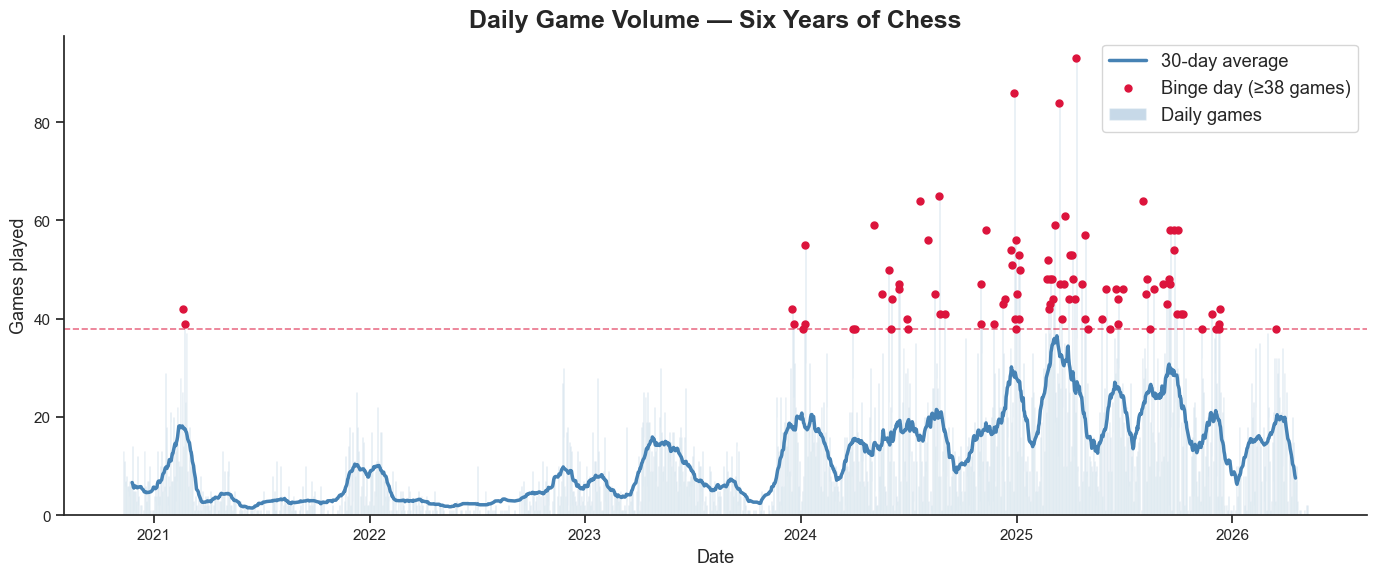

In [4]:
fig, ax = plt.subplots()

# raw daily bars (light, in the background)
ax.bar(
    daily["date"],
    daily["games"],
    color="steelblue",
    alpha=0.3,
    width=1,
    label="Daily games"
)

# 30-day trend line
ax.plot(
    daily["date"],
    daily["rolling_avg"],
    color="steelblue",
    linewidth=2.5,
    label="30-day average"
)

# highlight binge days
ax.scatter(
    binge_days["date"],
    binge_days["games"],
    color="crimson",
    s=25,
    zorder=5,
    label=f"Binge day (≥{binge_threshold:.0f} games)"
)

# binge threshold line
ax.axhline(
    binge_threshold,
    color="crimson",
    linestyle="--",
    alpha=0.6,
    linewidth=1.2
)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.set_title("Daily Game Volume — Six Years of Chess")
ax.set_xlabel("Date")
ax.set_ylabel("Games played")
ax.legend()

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

fig.savefig(PLOTS_DIR / "daily_volume.png", dpi=300, bbox_inches="tight")

---

## 2 — Requeue speed

**What we're looking for:** how many seconds pass between one game ending and the
next one starting. A short requeue time — especially after a loss — is one of the
clearest behavioral signals of compulsive play. The user is not pausing to reflect;
they are immediately seeking the next game.

We compare requeue speed after wins vs losses to test whether losing makes the
user *more* likely to jump straight back in.

In [5]:
# time between end of game N and start of game N+1
# we use game start times as a proxy (end time is not in the dataset)
# so we measure start-to-start gap, which still captures requeue urgency

df["next_game_start"] = df["date"].shift(-1)
df["gap_seconds"] = (
    df["next_game_start"] - df["date"]
).dt.total_seconds()

# keep only gaps that are plausibly within the same session:
# more than 10s (not duplicates) and less than 2 hours (not a new day)
requeue = df[
    (df["gap_seconds"] > 10) &
    (df["gap_seconds"] < 7200)
].copy()

# convert to minutes for readability
requeue["gap_minutes"] = requeue["gap_seconds"] / 60

# classify the result of the current game
requeue["result_label"] = requeue["result"]

print("Median requeue time by result (minutes):")
print(
    requeue.groupby("result_label")["gap_minutes"]
    .median()
    .round(2)
)

Median requeue time by result (minutes):
result_label
draw    6.02
loss    8.17
win     6.30
Name: gap_minutes, dtype: float64


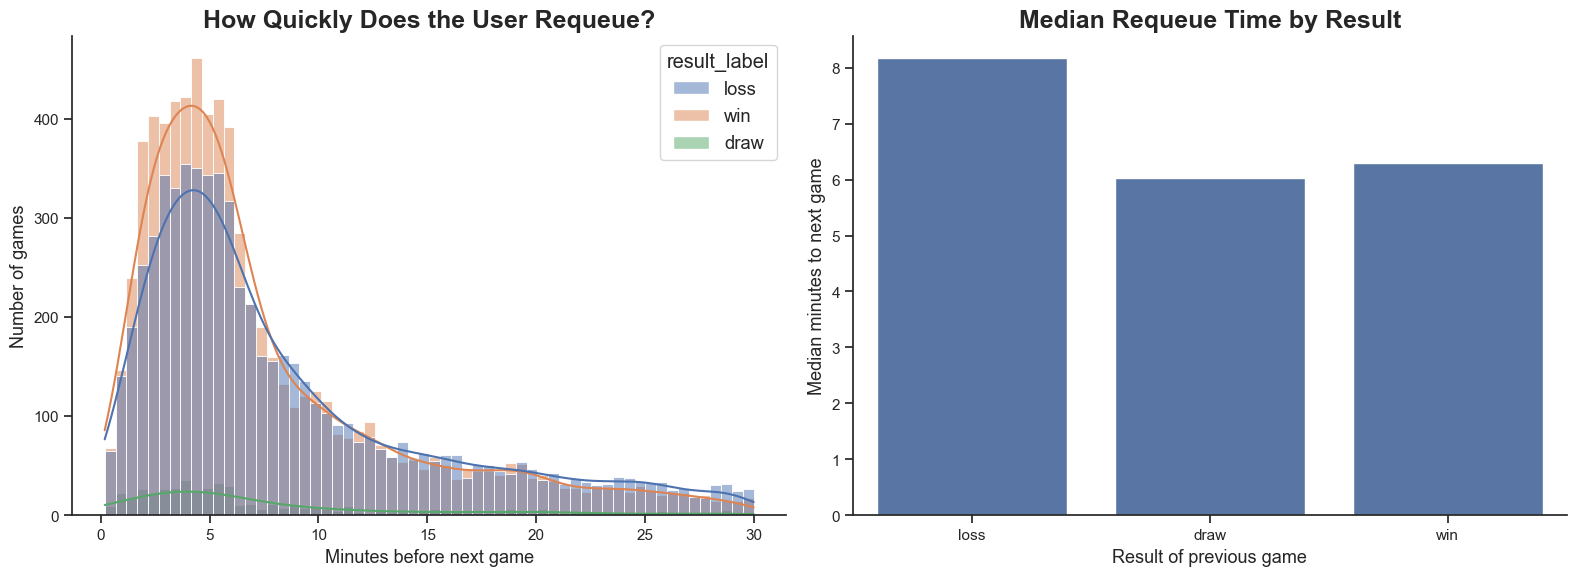

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- left: distribution of requeue times (capped at 30 min for readability) ---
ax = axes[0]

sns.histplot(
    data=requeue[requeue["gap_minutes"] <= 30],
    x="gap_minutes",
    hue="result_label",
    kde=True,
    bins=60,
    alpha=0.5,
    ax=ax
)

ax.set_title("How Quickly Does the User Requeue?")
ax.set_xlabel("Minutes before next game")
ax.set_ylabel("Number of games")
sns.despine(ax=ax)

# --- right: median requeue time by result ---
ax2 = axes[1]

median_requeue = (
    requeue.groupby("result_label")["gap_minutes"]
    .median()
    .reset_index()
    .sort_values("gap_minutes")
)

sns.barplot(
    data=median_requeue,
    x="result_label",
    y="gap_minutes",
    order=["loss", "draw", "win"],
    ax=ax2
)

ax2.set_title("Median Requeue Time by Result")
ax2.set_xlabel("Result of previous game")
ax2.set_ylabel("Median minutes to next game")
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

fig.savefig(PLOTS_DIR / "requeue_speed.png", dpi=300, bbox_inches="tight")

---

## 3 — Late night sessions

**What we're looking for:** games played after 22:00. This is the clearest sign
that chess is interfering with the user's life — they are sacrificing sleep.

We also check whether performance drops at night. If the user plays worse but
keeps playing anyway, that reinforces the compulsion narrative.

In [7]:
# classify time of day into human-readable blocks
def time_of_day(hour):
    if 5 <= hour < 12:
        return "Morning (5–12)"
    elif 12 <= hour < 18:
        return "Afternoon (12–18)"
    elif 18 <= hour < 22:
        return "Evening (18–22)"
    else:
        return "Late night (22–5)"

df["time_block"] = df["hour"].apply(time_of_day)

# volume and performance by time block
time_stats = (
    df.groupby("time_block")
    .agg(
        games=("url", "count"),
        win_rate=("score", "mean")
    )
    .reset_index()
)

# order the blocks chronologically
block_order = [
    "Morning (5–12)",
    "Afternoon (12–18)",
    "Evening (18–22)",
    "Late night (22–5)"
]
time_stats["time_block"] = pd.Categorical(
    time_stats["time_block"],
    categories=block_order,
    ordered=True
)
time_stats = time_stats.sort_values("time_block")

late_night_pct = (
    df[df["time_block"] == "Late night (22–5)"].shape[0] / len(df) * 100
)
print(f"Late night games: {late_night_pct:.1f}% of all games")

Late night games: 21.0% of all games


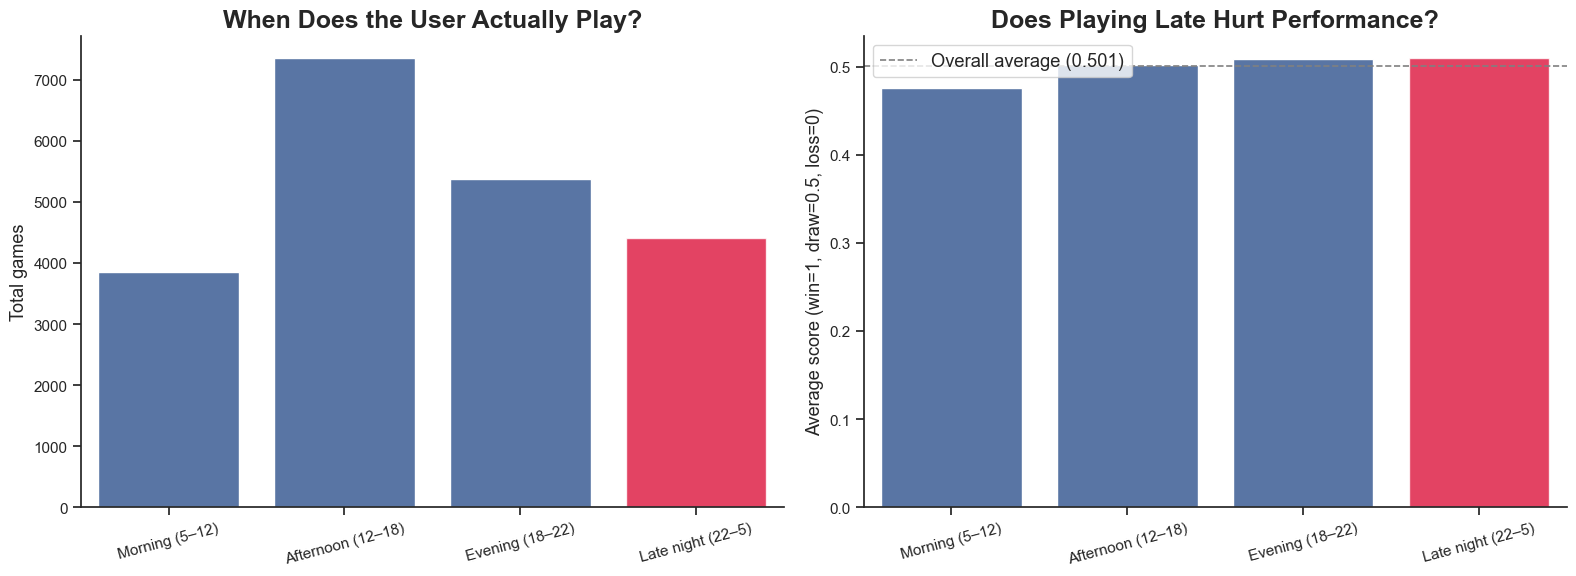

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- left: volume by time block ---
ax = axes[0]

bars = sns.barplot(
    data=time_stats,
    x="time_block",
    y="games",
    order=block_order,
    ax=ax
)

# highlight the late night bar in red
for i, bar in enumerate(bars.patches):
    if block_order[i] == "Late night (22–5)":
        bar.set_facecolor("crimson")
        bar.set_alpha(0.8)

ax.set_title("When Does the User Actually Play?")
ax.set_xlabel("")
ax.set_ylabel("Total games")
ax.tick_params(axis="x", rotation=15)
sns.despine(ax=ax)

# --- right: win rate by time block ---
ax2 = axes[1]

bars2 = sns.barplot(
    data=time_stats,
    x="time_block",
    y="win_rate",
    order=block_order,
    ax=ax2
)

for i, bar in enumerate(bars2.patches):
    if block_order[i] == "Late night (22–5)":
        bar.set_facecolor("crimson")
        bar.set_alpha(0.8)

# reference line at overall average
ax2.axhline(
    df["score"].mean(),
    color="gray",
    linestyle="--",
    linewidth=1.2,
    label=f"Overall average ({df['score'].mean():.3f})"
)

ax2.set_title("Does Playing Late Hurt Performance?")
ax2.set_xlabel("")
ax2.set_ylabel("Average score (win=1, draw=0.5, loss=0)")
ax2.tick_params(axis="x", rotation=15)
ax2.legend()
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

fig.savefig(PLOTS_DIR / "late_night.png", dpi=300, bbox_inches="tight")

---

## 4 — Session length

**What we're looking for:** how many games the user plays in a single sitting.

We define a **session** as a continuous block of games where the gap between
consecutive games never exceeds 2 hours. A new session starts when the gap
exceeds that threshold.

We then look at the distribution of session lengths and flag the longest ones.

In [9]:
SESSION_GAP_HOURS = 2  # gap in hours that defines a new session

df["gap_to_next"] = (
    df["date"].shift(-1) - df["date"]
).dt.total_seconds() / 3600  # in hours

# a new session starts where the gap from the PREVIOUS game exceeded the threshold
df["new_session"] = (
    df["gap_to_next"].shift(1).isna() |       # first game ever
    (df["gap_to_next"].shift(1) > SESSION_GAP_HOURS)  # gap was too long
)

df["session_id"] = df["new_session"].cumsum()

sessions = (
    df.groupby("session_id")
    .agg(
        games=("url", "count"),
        session_start=("date", "min"),
        session_end=("date", "max"),
        win_rate=("score", "mean")
    )
    .reset_index()
)

sessions["duration_hours"] = (
    sessions["session_end"] - sessions["session_start"]
).dt.total_seconds() / 3600

print(f"Total sessions identified: {len(sessions):,}")
print(f"Median session length: {sessions['games'].median():.0f} games")
print(f"Mean session length:   {sessions['games'].mean():.1f} games")
print(f"Longest session:       {sessions['games'].max()} games")
print()
print("Top 10 longest sessions:")
print(
    sessions.nlargest(10, "games")[
        ["session_start", "games", "duration_hours", "win_rate"]
    ].to_string(index=False)
)

Total sessions identified: 3,689
Median session length: 3 games
Mean session length:   5.7 games
Longest session:       92 games

Top 10 longest sessions:
      session_start  games  duration_hours  win_rate
2024-12-28 10:40:47     92       14.038333  0.494565
2025-03-14 07:21:23     85       16.730278  0.547059
2024-07-21 11:54:09     65       12.667222  0.538462
2025-08-03 13:31:16     63       10.816667  0.523810
2024-05-04 11:31:49     59       11.348056  0.457627
2024-11-10 17:34:38     59        7.204722  0.440678
2025-04-12 11:08:45     59        6.856667  0.576271
2025-09-18 09:14:56     57        9.138333  0.552632
2025-03-24 18:10:25     56        5.939167  0.446429
2025-02-26 19:24:00     55        6.059722  0.563636


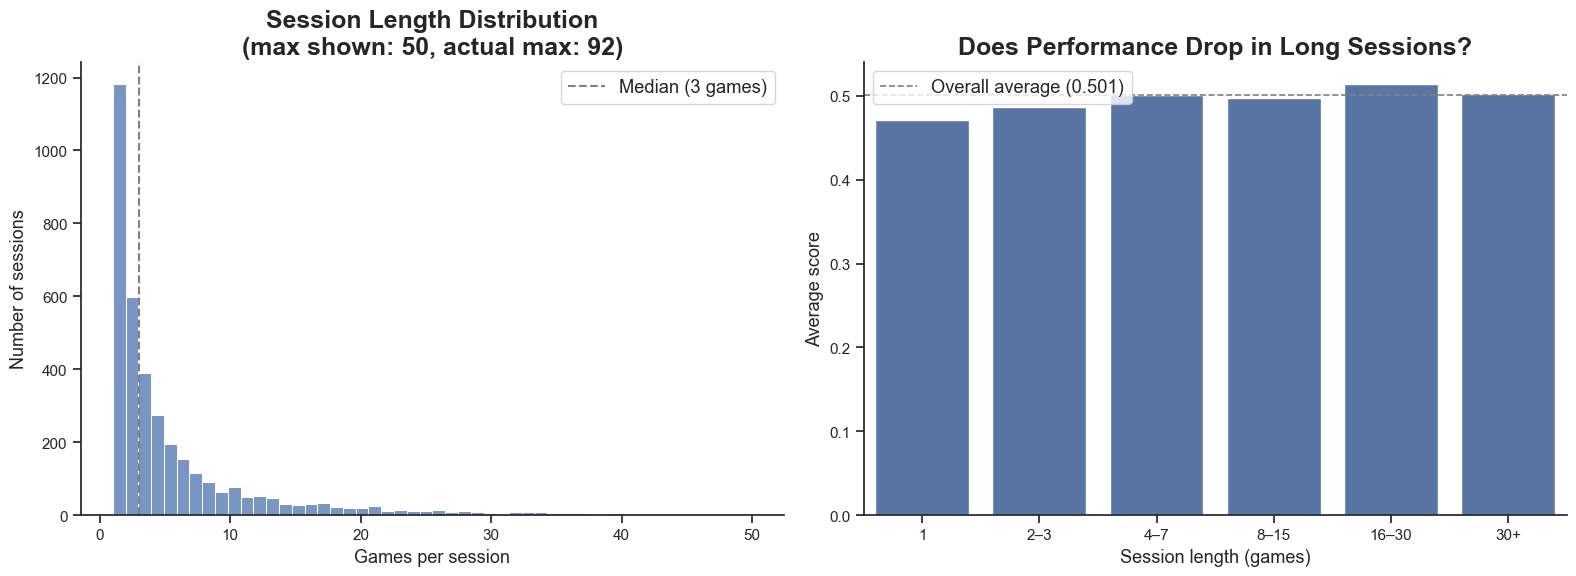

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- left: session length distribution ---
ax = axes[0]

# cap display at 50 games for readability; the tail is shown in the title
cap = 50
sns.histplot(
    data=sessions[sessions["games"] <= cap],
    x="games",
    bins=cap,
    ax=ax
)

ax.axvline(
    sessions["games"].median(),
    color="gray",
    linestyle="--",
    label=f"Median ({sessions['games'].median():.0f} games)"
)

ax.set_title(f"Session Length Distribution\n(max shown: {cap}, actual max: {sessions['games'].max()})")
ax.set_xlabel("Games per session")
ax.set_ylabel("Number of sessions")
ax.legend()
sns.despine(ax=ax)

# --- right: win rate vs session length ---
ax2 = axes[1]

# bucket sessions into length groups
bins = [0, 1, 3, 7, 15, 30, sessions["games"].max() + 1]
labels = ["1", "2–3", "4–7", "8–15", "16–30", "30+"]

sessions["length_bucket"] = pd.cut(
    sessions["games"],
    bins=bins,
    labels=labels,
    right=True
)

bucket_perf = (
    sessions.groupby("length_bucket", observed=True)["win_rate"]
    .mean()
    .reset_index()
)

sns.barplot(
    data=bucket_perf,
    x="length_bucket",
    y="win_rate",
    order=labels,
    ax=ax2
)

ax2.axhline(
    df["score"].mean(),
    color="gray",
    linestyle="--",
    linewidth=1.2,
    label=f"Overall average ({df['score'].mean():.3f})"
)

ax2.set_title("Does Performance Drop in Long Sessions?")
ax2.set_xlabel("Session length (games)")
ax2.set_ylabel("Average score")
ax2.legend()
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

fig.savefig(PLOTS_DIR / "session_length.png", dpi=300, bbox_inches="tight")

---

## 5 — Yearly volume trend

**What we're looking for:** is usage accelerating, stable, or declining?

A healthy casual habit tends to be stable or declining over time as the novelty
wears off. Accelerating volume — especially if paired with the other signals above
— suggests the behavior is intensifying rather than moderating.

Note: 2020 is a partial year (account opened November 2020) and 2026 is ongoing,
so both are annotated accordingly.

In [11]:
yearly = (
    df.groupby("year")
    .agg(
        games=("url", "count"),
        win_rate=("score", "mean")
    )
    .reset_index()
)

# flag the partial years for annotation
partial_years = [
    df["year"].min(),   # account opened mid-year
    df["year"].max()    # current year, not yet complete
]

print(yearly.to_string(index=False))

 year  games  win_rate
 2020    287  0.526132
 2021   1715  0.508455
 2022   1208  0.498344
 2023   2917  0.495201
 2024   5820  0.501718
 2025   7610  0.500131
 2026   1450  0.496897


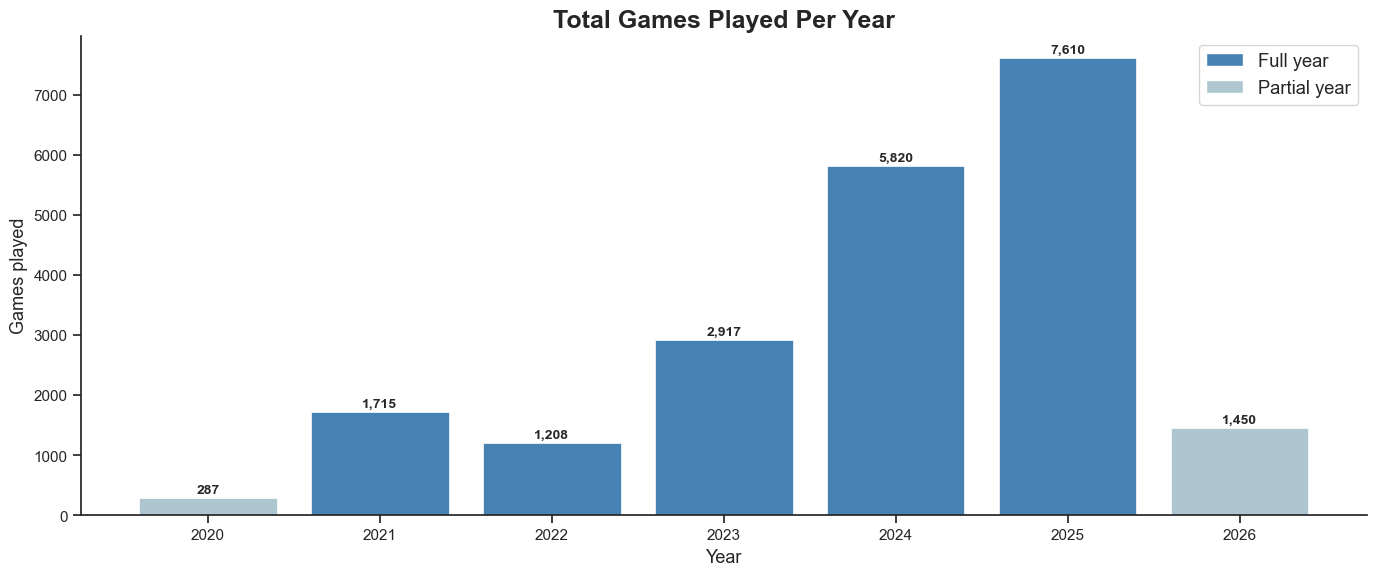

In [16]:
fig, ax = plt.subplots()

colors = [
    "#aec6cf" if y in partial_years else "steelblue"
    for y in yearly["year"]
]

bars = ax.bar(
    yearly["year"].astype(str),
    yearly["games"],
    color=colors,
    edgecolor="white",
    linewidth=0.5
)

# add game count label on each bar
for bar, games in zip(bars, yearly["games"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f"{games:,}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )


ax.set_title("Total Games Played Per Year")
ax.set_xlabel("Year")
ax.set_ylabel("Games played")

# custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="steelblue", label="Full year"),
    Patch(facecolor="#aec6cf", label="Partial year")
]
ax.legend(handles=legend_elements)

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

fig.savefig(PLOTS_DIR / "yearly_volume.png", dpi=300, bbox_inches="tight")

---

## Summary


| Signal | What to look for | What the data showed |
|---|---|---|
| Daily volume | Spikes far above baseline | Max binge day: **93 games**, Number of binge days: **93** |
| Requeue speed | Reward and tension loop, fastest after draws and wins | Median gap by result: **Draw 6.02**, **Win 6.30**, **Loss 8.17** |
| Late night play | Significant % of games after 22:00 | **21% of all games** |
| Session length | Long sessions with declining performance | Median session: **3 games**, Longest session: **93 games**, **Performance not impacted by session length** |
| Yearly trend | Volume increasing over time | **344% increase** from 2021 to 2025 |

**Recommendations are:** 
- Set a hard daily game limit
- Add a mandatory cooldown after a losing streak
- Block access after 22:00
- End sessions after X games regardless of result